# Notebook to train the model for gender classification

### 1. Import

In [1]:
import pandas as pd
import numpy as np
import os
import pickle
from pathlib import Path

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import precision_score, recall_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
import sys
sys.path.append('..')
from shoppingassistant.helper_functions import load_images_and_labels, split_train_val

### 2. Load data and images

In [2]:
X, y, categories = load_images_and_labels(
        target_column='index_group_name',
        num_images=None  # None = all images, or set to 100 for testing
    )

num_classes = len(categories)

Using all 4892 images
Categories (3): ['Baby/Children', 'Ladieswear', 'Menswear']
 Loaded 4892 images
 X shape: (4892, 256, 256, 3)
 y shape: (4892,)


### 3. One Hot encode labels

In [3]:
y_encoded = to_categorical(y, num_classes = num_classes)
print(f"Labels shape after encoding: {y_encoded.shape}")

Labels shape after encoding: (4892, 3)


### 4. Split data for training and testing

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2,
                                             stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2,
                                             stratify=y_train, random_state=42)

print(f"Training data size: {X_train.shape} {y_train.shape}")
print(f"Validation data size: {X_val.shape} {y_val.shape}")
print(f"Test data size: {X_test.shape} {y_test.shape}")

Training data size: (3130, 256, 256, 3) (3130, 3)
Validation data size: (783, 256, 256, 3) (783, 3)
Test data size: (979, 256, 256, 3) (979, 3)


### 5. Compute class weights for inbalanced data

In [21]:
y_int = np.argmax(y_encoded, axis=1)  # Converts to integers: 0, 1, 2

classes = np.unique(y_int)
cw = class_weight.compute_class_weight(class_weight='balanced',
                                        classes=classes,
                                        y=y_int)
class_weights = dict(zip(classes, cw))
print("Class weights:", class_weights)

Class weights: {np.int64(0): np.float64(0.7480122324159021), np.int64(1): np.float64(0.7950593206565902), np.int64(2): np.float64(2.4669692385274837)}


### 6. Build and compile model using pre-trained model

In [ ]:
# Build model
data_augmentation = Sequential([
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.2),
            layers.RandomZoom(0.2),
            layers.RandomTranslation(0.1, 0.1),

        ])


base_model = InceptionV3(
    weights="imagenet",
    include_top=False,
    input_shape = (256,256,3)
)
base_model.trainable = False   # Freeze for first stage
input_shape = (256,256,3)
inputs = layers.Input(shape=input_shape)
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(512, activation='relu')(x)
#x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation='relu')(x)
#x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)

outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)

# Compile
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("Model built and compiled")
model.summary()


Model built and compiled


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 6, 6, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,016,483 (87.80 MB)

 Trainable params: 1,213,699 (4.63 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

### 7. Train model

In [24]:
model_path = '../models/gender_classifier.keras'
epochs = 40

callbacks = [
        EarlyStopping(monitor="val_accuracy", patience=10, restore_best_weights=True),
        ModelCheckpoint(model_path, save_best_only=True, monitor="val_accuracy", mode="max")
    ]

print("🚀 Training started...")
history = model.fit(X_train, y_train,
                validation_data=(X_val,y_val),
                epochs=epochs,
                class_weight=class_weights,
                batch_size=32,
                callbacks=callbacks)

print("🎉 Training complete!")


🚀 Training started...
Epoch 1/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.6636 - loss: 0.7675 - val_accuracy: 0.6986 - val_loss: 0.7087
Epoch 2/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - accuracy: 0.6757 - loss: 0.7231 - val_accuracy: 0.6794 - val_loss: 0.7182
Epoch 3/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.6901 - loss: 0.7099 - val_accuracy: 0.7152 - val_loss: 0.6644
Epoch 4/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.6834 - loss: 0.6901 - val_accuracy: 0.6603 - val_loss: 0.7262
Epoch 5/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.6901 - loss: 0.6822 - val_accuracy: 0.7241 - val_loss: 0.6444
Epoch 6/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.7042 - loss: 0.6718 - val_accuracy: 0.7344 - val_loss: 0.6365
Epoch 7/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.7268 - loss: 0.6341 - val_accuracy: 0.6909 - val_loss: 0.7201
Epoch 8/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.7217 - loss: 0.6350 - va

### 8. Evaluate model

In [29]:
loss, accuracy = model.evaluate(X_val, y_val)

# Get predictions
y_pred = model.predict(X_test)
y_true = np.argmax(y_test, axis=1)
y_pred_labels = np.argmax(y_pred, axis=1)

precision = precision_score(y_true, y_pred_labels, average='macro')
recall = recall_score(y_true, y_pred_labels, average='macro')

print(f"{'='* 100}")
print(f"acuuracy: {accuracy}")
print(f"precision: {precision}")
print(f"recall: {recall}")
print(f"{'='* 100}")


25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 770ms/step - accuracy: 0.7599 - loss: 0.5853
31/31 ━━━━━━━━━━━━━━━━━━━━ 24s 778ms/step
acuuracy: 0.7598978281021118
precision: 0.688879802539276
recall: 0.7093680053734966


### 9. Plot accuracy and loss

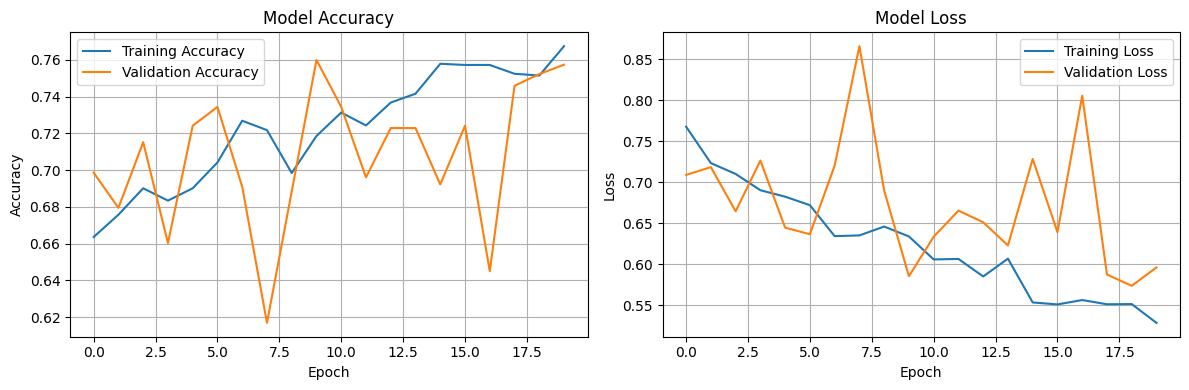

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### 10. Model prediction from our data

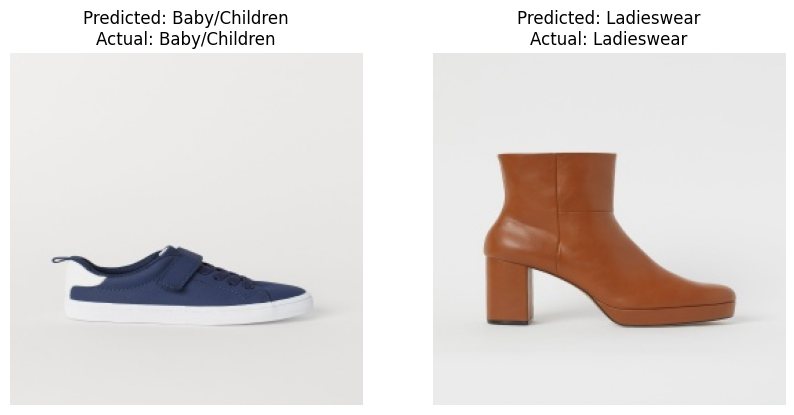

In [41]:
test_images = X_test[0:2]   # shape (2, H, W, C)
test_labels = y_test[0:2]   # corresponding labels

predictions = model.predict(test_images, verbose=0)

# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for i, ax in enumerate(axes):
    pred_idx = np.argmax(predictions[i])
    pred_gender= categories[pred_idx]

    actual_idx = np.argmax(test_labels[i])
    actual_gender = categories[actual_idx]

    ax.imshow(test_images[i])
    ax.set_title(f"Predicted: {pred_gender}\nActual: {actual_gender}")
    ax.axis('off')

plt.show()

### 11. Model prediction from random image

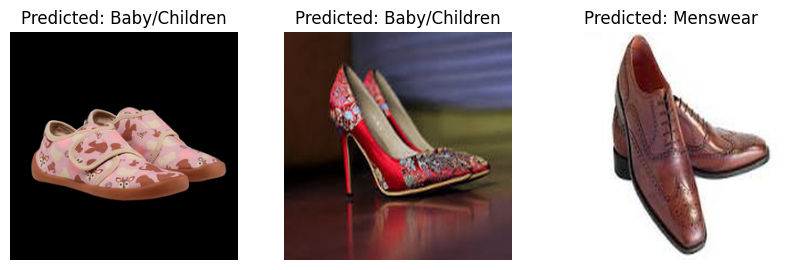

In [ ]:
test_images_raw = ['../raw_data/test_images/kids.jpg',
                   '../raw_data/test_images/women.jpg',
                   '../raw_data/test_images/men.jpg']
test_images = []

from shoppingassistant.helper_functions import preprocess_single_image

# Preprocess each image
for img_path in test_images_raw:
    test_images.append(preprocess_single_image(img_path))

# Stack correctly into one batch
test_images = np.vstack(test_images)  # shape: (2, 256, 256, 3)

predictions = model.predict(test_images, verbose=0)

# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 3, figsize=(10, 5))

for i, ax in enumerate(axes):
    pred_idx = np.argmax(predictions[i])
    pred_gender = categories[pred_idx]

    ax.imshow(test_images[i])
    ax.set_title(f"Predicted: {pred_gender}")
    ax.axis('off')

plt.show()
